In [1]:
!echo $LD_LIBRARY_PATH, $CONDA_PREFIX

/hpc/group/cosmology/nlc38/anaconda3/envs/dp2_smhm/lib, /hpc/group/cosmology/nlc38/anaconda3/envs/dp2_smhm


In [3]:
import pyccl as ccl
import numpy as np
from scipy.integrate import simpson
import matplotlib.pyplot as plt

In [78]:
import matplotlib as mpl
mpl.use('Agg')
mpl.rcParams['font.size'] = 16
mpl.rcParams['text.usetex'] = 'True'

In [5]:
cosmo = ccl.CosmologyVanillaLCDM()

# Here we use a mass definition with Delta = 200 times the matter density,
# Note: We are defining mass w.r.t the matter density, not the critical density, which is more common in some contexts. 
# keep in mind when instantiating base cl.halos.HaloProfileHOD class with mass_def and concentration-mass relation, as both should follow same rho_type convention.
# If they differ, cl.halos.HaloProfileHOD will raise an error, which is good to prevent mistakes.
hmd_200m = ccl.halos.MassDef200m
# The Duffy2008 concentration-mass relation, by default it will be initialized for S.O masses with Delta=Delta_vir of Delta_vir=200
# critical density based halo mass :math:`M_{200c}`.  (Evolution of Mvir (SO based mass even when Delta is fixed to 200) with redshift is shown below.)
cM = ccl.halos.ConcentrationDuffy08(mass_def=hmd_200m)
assert cM.mass_def == hmd_200m, "This is what you've to be careful of!"
assert cM.mass_def.name == hmd_200m.name, "Same issue"

In [6]:
hmd_200m?

Type:        MassDef
String form: MassDef(Delta=200, rho_type=matter)
File:        /hpc/group/cosmology/nlc38/anaconda3/envs/dp2_smhm/lib/python3.14/site-packages/pyccl/halos/massdef.py
Docstring:  
Halo mass definition. Halo masses are defined in terms of an overdensity
parameter :math:`\Delta` and an associated density :math:`X` (either the
matter density or the critical density):

.. math::
    M_\Delta = \frac{4 \pi}{3} \Delta\,\rho_X\, R_\Delta^3

where :math:`R_\Delta` is the halo radius. This object also holds methods
to translate between :math:`R_\Delta` and :math:`M_\Delta`, and to
translate masses between different definitions if a concentration-mass
relation is provided.

You may also define halo masses based on a Friends-of-Friends algorithm,
in which case simply pass ``Delta='fof'`` below.

Args:
    Delta (:obj:`float`): overdensity parameter. Pass ``'vir'`` if using virial
        overdensity. Pass ``'fof'`` for Friends-of-Friends halos.
    rho_type (:obj:`str`): either

### How the $M_{vir}$ changes with redshift even if you keep the $\Delta=200$ fixed.

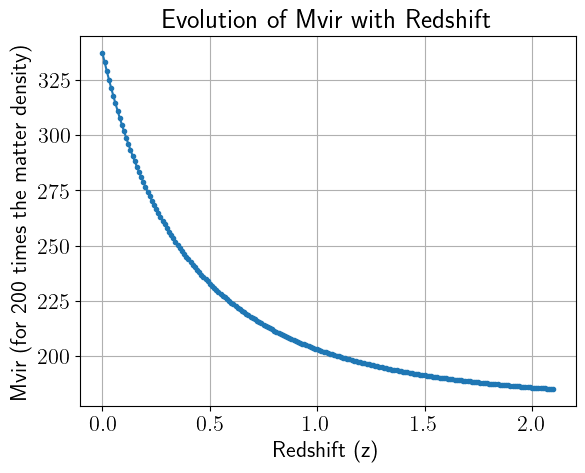

In [ ]:
# Checking how Mvir evolves with redshift for this cosmology and fixed mass definition of 200 times the matter density.
z = np.linspace(0, 2.1, 211)
aa = 1/(1+z)
mvir=[]
for a in aa:
    mvir.append(hmd_200m.get_Delta_vir(cosmo, a))

plt.plot(z, mvir, ".-")
plt.xlabel('Redshift (z)')
plt.ylabel('Mvir (for 200 times the matter density)')
plt.title('Evolution of Mvir with Redshift')
plt.grid()
# plt.savefig("Mvir_vs_scaleFactor_for_M200m_mass_def.png", bbox_inches='tight', dpi=200)
plt.show()

### Zecharegkas and Chang et al 2026 HOD model 

In [ ]:
from typing import Union, Optional

class CacciatoHOD(ccl.halos.HaloProfileHOD):
    def __init__(self, *, 
                 mass_def: Union[str, ccl.halos.MassDef], 
                 cM_rel: Union[str, ccl.halos.Concentration],
                 Lmin, Lmax, N_L=64,
                 log_L0=9.95, lM_1=11.24,
                 gamma_1=3.18, gamma_2=0.245,
                 sigma_c=0.157, alpha_s=-1.18,
                 b_0=-1.17, b_1=1.53*0.739, b_2=-0.217*0.739**2,
                 fh=1., fs=1.
                 ) -> None:
        """
        Custom HOD model based on Cacciato et al.
        
        Args:
            mass_def: Halo mass definition (e.g., '200m' or a MassDef object).
            cM_rel: Concentration-mass relation (e.g., 'Duffy08' or a Concentration object).
            **kwargs: Additional HOD parameters passed to the parent class.
        """
        # Initialize the parent class with essential parameters
        # overwrite more parent attr if you need.
        super().__init__(mass_def=mass_def, concentration=cM_rel)

        # fh, fs the scaling of cM_rel, to be include in _usat_real/fourier
        # b_1 and b_2 have been rescaled by h from Cacciato et al. 2013
        self.cM = cM_rel


In [ ]:
### CSMF model

In [15]:
from typing import Union, Optional
from scipy.special import erf
from scipy.special import gammaincc, gamma

class CacciatoHOD(ccl.halos.HaloProfileHOD):
    def __init__(self, *, 
                 mass_def: Union[str, ccl.halos.MassDef], 
                 cM_rel: Union[str, ccl.halos.Concentration],
                 log_L1, log_L2,
                 log_L0=9.95, log_M1=11.24,
                 gamma_1=3.18, gamma_2=0.245,
                 sigma_c=0.157, alpha_s=-1.18,
                 b_0=-1.17, b_1=1.53*0.739, b_2=-0.217*0.739**2,
                 fh=1., fs=1.
                 ) -> None:
        """
        HOD model based on Cacciato et al. (2013) has 9 free parameters as listed below:
        - log_L0: log10 of the normalization factor (L0) of the central galaxy
            luminosity function L_c(M) as a function of halo mass. Here the central
            galaxies are those that belong in the sample we're modeling.
        - log_M1: log10 of the characteristic halo mass scale (M1).
        - gamma_1: slope of the central galaxy luminosity function at the low-mass end (M << M1).
        - gamma_2: slope of the central galaxy luminosity function at the high-mass end (M >> M1).
        - sigma_c: scatter in the luminosities of central galaxies in the sample
            populating a fixed halo mass, M.
        - alpha_s: faint end of the slope of the satellite galaxy occupation
            number. Independent of (M,z), can be changed.
        - b_0, b_1, b_2: parameters for the satellite galaxy luminosity function.

        Args:
            mass_def: Halo mass definition (e.g., '200m' or a MassDef object).
            cM_rel: Concentration-mass relation (e.g., 'Duffy08' or a Concentration object).
            log_L1, log_L2: luminosity bin of the lens sample we're modeling in log10.
            log_L0, log_M1, gamma_1, gamma_2, sigma_c, alpha_s, b_0, b_1, b_2:
                Free parameters of the CLF model, as described above.
        """
        # Initialize the parent class with essential parameters
        # overwrite more parent attr if you need.
        super().__init__(mass_def=mass_def, concentration=cM_rel)

        # fh, fs the scaling of cM_rel, to be include in _usat_real/fourier
        # b_1 and b_2 have been rescaled by h from Cacciato et al. 2013
        self.cM = cM_rel

        # sample luminosity range
        self.log_L1 = log_L1
        self.log_L2 = log_L2
        # CLF free parameters
        self.log_L0 = log_L0
        self.log_M1 = log_M1
        self.gamma_1 = gamma_1
        self.gamma_2 = gamma_2
        self.sigma_c = sigma_c
        self.alpha_s = alpha_s # independent of halo mass in this work, but can be made mass dependent if needed.
        self.b_0 = b_0
        self.b_1 = b_1
        self.b_2 = b_2
        #constants
        self.loge = np.log10(np.e)

    def _log_Lc(self, logM):
        """Characteristic luminosity of central galaxies in the sample as a
        function of halo mass."""
        return self.log_L0 + self.gamma_1 *(logM - self.log_M1) - \
               np.log10( (1 + 10**(logM-self.log_M1)) ** (self.gamma_1 - self.gamma_2) )

    def _log_L_star_s(self, logM):
        """Characteristic luminosity of satellite galaxies in the sample as a
        function of halo mass."""
        return np.log10(0.562) + self._log_Lc(logM)

    def _log_phi_star_s(self, logM):
        """The ingredients, M_12, b_0, b_1, b_2, are unitless and required to
        compute the normalization of the satellite CLF.  None of these are
        physically motivated, but they are just fitting functions to the CLF of
        Yang et al 2008 and then in Cacciato et al. 2013."""
        logM12 = logM - 12 # CCL convension: Solar mass, not h^-1 Solar mass, so no need to include h here.
        log_phi_star_s = self.b_0 + self.b_1 * logM12 + self.b_2 * logM12**2
        return log_phi_star_s

    def _Nc(self, logM, a): # ---check math
        """Overried the parent method to compute the mean occupation number of
        central galaxies in the sample, which is the integral of Phi_c(L|M) over
        the luminosity range of the sample."""
        logLc = self._log_Lc(logM)
        # Standardized variables for the erf function
        denom = np.sqrt(2) * self.sigma_c
        term_max = (self.log_L2 - logLc) / denom
        term_min = (self.log_L1 - logLc) / denom

        return 0.5 * (erf(term_max) - erf(term_min))
    
    def _Ns(self, logM, a): # ------ check math
        log_phi_s = self._log_phi_star_s(logM)
        logLs = self._log_L_star_s(logM)

        # The exponent for the Gamma function
        # Note: (alpha + 1) / 2
        shape = (self.alpha_s + 1) / 2.0
        
        # Limits for the integral
        # Incomplete Gamma integrated from x to infinity
        x_min = 2.0*(self.log_L1 - logLs)
        x_max = 2.0*(self.log_L2 - logLs)

        # gammaincc is the regularized form: Gamma(a, x) / Gamma(a)
        # So we multiply by gamma(shape) to get the actual integral value
        integral_min = gammaincc(shape, 10**x_min) * gamma(shape)
        integral_max = gammaincc(shape, 10**x_max) * gamma(shape)

        return (10**log_phi_s / 2.0) * (integral_min - integral_max)


In [16]:
hod = CacciatoHOD(mass_def=hmd_200m, cM_rel=cM, log_L1=np.log10(1.5e7), log_L2=np.log10(5.6e9))
logM = np.linspace(8,16,128)
Ns = hod._Ns(logM, 1.)
Nc = hod._Nc(logM, 1.)

In [44]:
Nc,Ns

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.48769885e-14, 8.05703837e-11, 9.96901255e-08, 2.94607966e-05,
        2.20336860e-03, 4.52520920e-02, 2.89547602e-01, 7.13853020e-01,
        9.51874983e-01, 9.96918580e-01, 9.99924496e-01, 9.99999254e-01,
        9.99999997e-01, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00, 9.99999961e-01, 9.99998300e-01,
        9.99962637e-01, 9.99548272e-01, 9.96729729e-01, 9.846519

In [87]:
mpl.use('inline')
%matplotlib inline

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/tmp/ipykernel_1165898/1128542097.py:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  ax.set_xlabel('$M$ [M$_\odot$]')


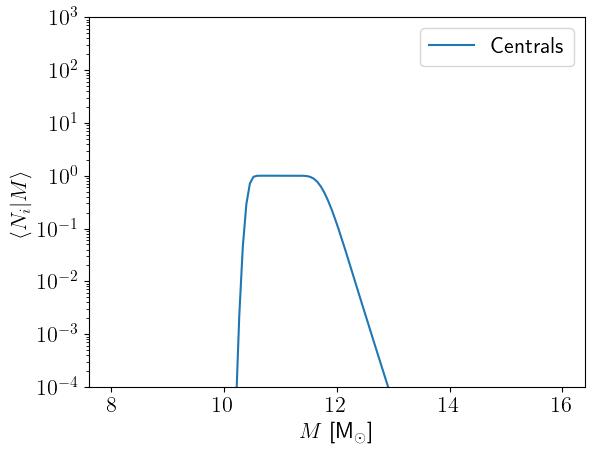

In [89]:
fig, ax = plt.subplots()
# ax.plot(logM, Ns, label='Satellites')
ax.plot(logM, Nc, label='Centrals')
ax.set_ylim(1e-4, 1e3)
ax.set_yscale('log')
ax.legend()
ax.set_xlabel('$M$ [M$_\odot$]')
ax.set_ylabel(r'$\langle N_i|M \rangle$')
# plt.savefig("Cacciato_HOD_Nc_Ns_vs_M.pdf", bbox_inches='tight', dpi=200)
plt.show()

### Make an HOD plot that is verified against some published work or a working code

<>:6: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:6: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/tmp/ipykernel_959148/2276955432.py:6: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  ax.set_xlabel('$M$ [M$_\odot$]')


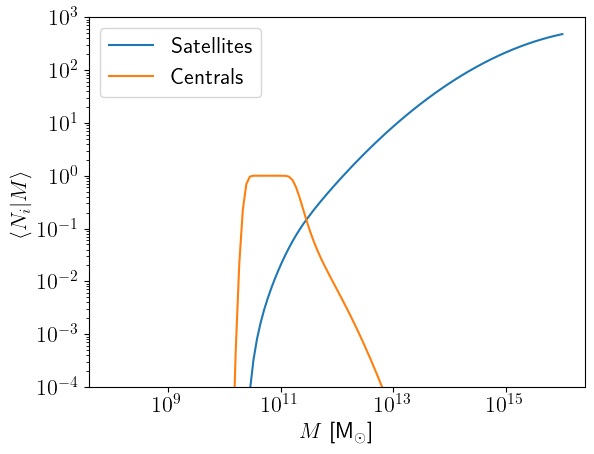

In [53]:
fig, ax = plt.subplots()
ax.loglog(mass_arr, Ns, label='Satellites')
ax.loglog(mass_arr, Nc, label='Centrals')
ax.set_ylim([1e-4, 1e3])
ax.legend()
ax.set_xlabel('$M$ [M$_\odot$]')
ax.set_ylabel(r'$\langle N_i|M \rangle$')
plt.savefig("Cacciato_HOD_Nc_Ns_vs_M.pdf", bbox_inches='tight', dpi=200)

My explorations with CCL